# Inferencia de Mamdani

Para x0 = 4:
Fuerza de activación α1: 0.5
Fuerza de activación α2: 0.5

Para x0 = 3.5:
Fuerza de activación α1: 0.75
Fuerza de activación α2: 0.25

Valor defuzzificado para x0 = 4: y0 = 12.498668315811173
Valor defuzzificado para x0 = 3.5: y0 = 11.446295196724893


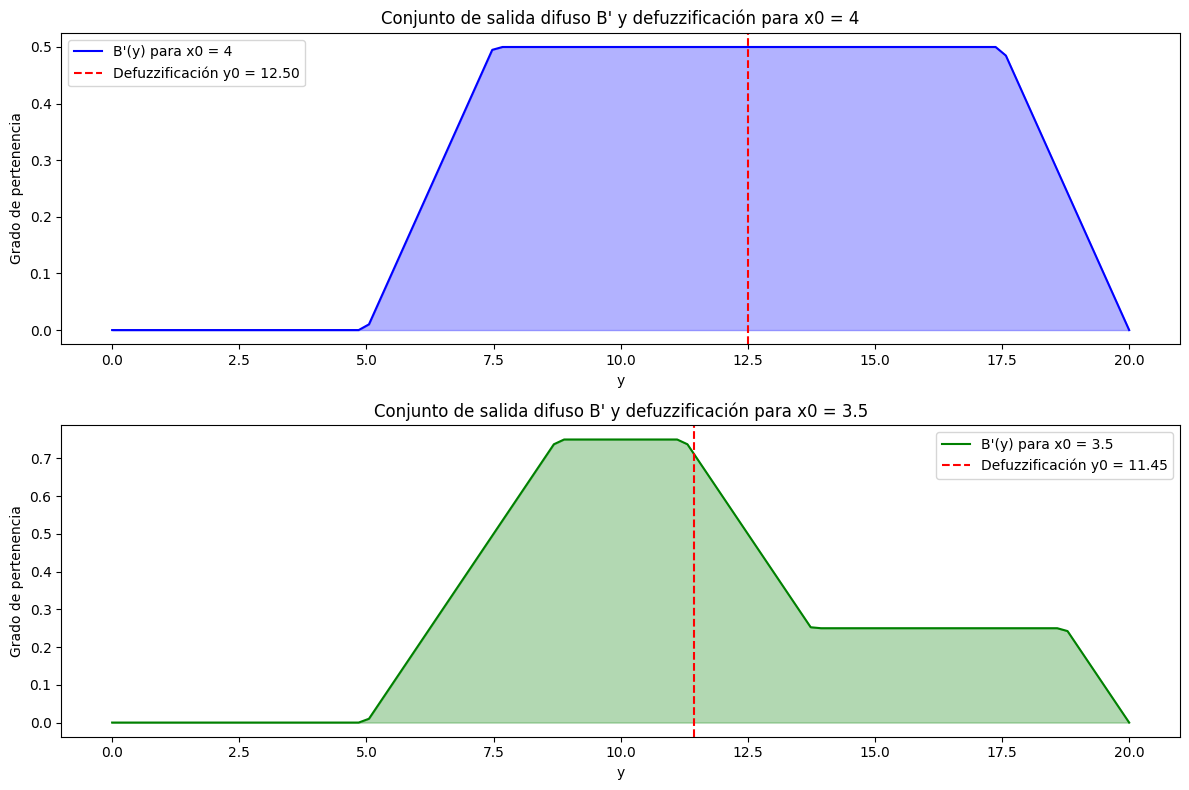

In [31]:
# Importar bibliotecas necesarias
import numpy as np
import matplotlib.pyplot as plt


# Función de pertenencia triangular
def triangular(x, a, b, c):
    if x <= a or x >= c:
        return 0
    elif a < x < b:
        return (x - a) / (b - a)
    elif b <= x < c:
        return (c - x) / (c - b)
    return 0


# Definir los conjuntos difusos
A1 = lambda x: triangular(x, 1, 3, 5)
A2 = lambda x: triangular(x, 3, 5, 7)
B1 = lambda y: triangular(y, 5, 10, 15)
B2 = lambda y: triangular(y, 10, 15, 20)

# Valores de entrada crisp
x0_a = 4
x0_b = 3.5

# Calcular las fuerzas de activación para cada valor de x0
alpha1_a = A1(x0_a)
alpha2_a = A2(x0_a)
alpha1_b = A1(x0_b)
alpha2_b = A2(x0_b)

print("Para x0 = 4:")
print(f"Fuerza de activación α1: {alpha1_a}")
print(f"Fuerza de activación α2: {alpha2_a}")

print("\nPara x0 = 3.5:")
print(f"Fuerza de activación α1: {alpha1_b}")
print(f"Fuerza de activación α2: {alpha2_b}")

# Generar el conjunto de salida difuso B' para cada caso
y_vals = np.linspace(0, 20, 100)
B_prime_a = np.maximum(
    np.minimum(alpha1_a, [B1(y) for y in y_vals]),
    np.minimum(alpha2_a, [B2(y) for y in y_vals]),
)
B_prime_b = np.maximum(
    np.minimum(alpha1_b, [B1(y) for y in y_vals]),
    np.minimum(alpha2_b, [B2(y) for y in y_vals]),
)


# Función de defuzzificación (centroide)
def defuzzify(y_vals, B_prime):
    return np.sum(y_vals * B_prime) / np.sum(B_prime)


# Calcular la defuzzificación para cada caso
y0_a = defuzzify(y_vals, B_prime_a)
y0_b = defuzzify(y_vals, B_prime_b)

print(f"\nValor defuzzificado para x0 = 4: y0 = {y0_a}")
print(f"Valor defuzzificado para x0 = 3.5: y0 = {y0_b}")

# Graficar los resultados
plt.figure(figsize=(12, 8))

# Graficar el caso para x0 = 4
plt.subplot(2, 1, 1)
plt.plot(y_vals, B_prime_a, label="B'(y) para x0 = 4", color="blue")
plt.fill_between(y_vals, B_prime_a, alpha=0.3, color="blue")
plt.axvline(
    x=y0_a, color="red", linestyle="--", label=f"Defuzzificación y0 = {y0_a:.2f}"
)
plt.title("Conjunto de salida difuso B' y defuzzificación para x0 = 4")
plt.xlabel("y")
plt.ylabel("Grado de pertenencia")
plt.legend()

# Graficar el caso para x0 = 3.5
plt.subplot(2, 1, 2)
plt.plot(y_vals, B_prime_b, label="B'(y) para x0 = 3.5", color="green")
plt.fill_between(y_vals, B_prime_b, alpha=0.3, color="green")
plt.axvline(
    x=y0_b, color="red", linestyle="--", label=f"Defuzzificación y0 = {y0_b:.2f}"
)
plt.title("Conjunto de salida difuso B' y defuzzificación para x0 = 3.5")
plt.xlabel("y")
plt.ylabel("Grado de pertenencia")
plt.legend()

plt.tight_layout()
plt.show()

# Inferencia de Godel

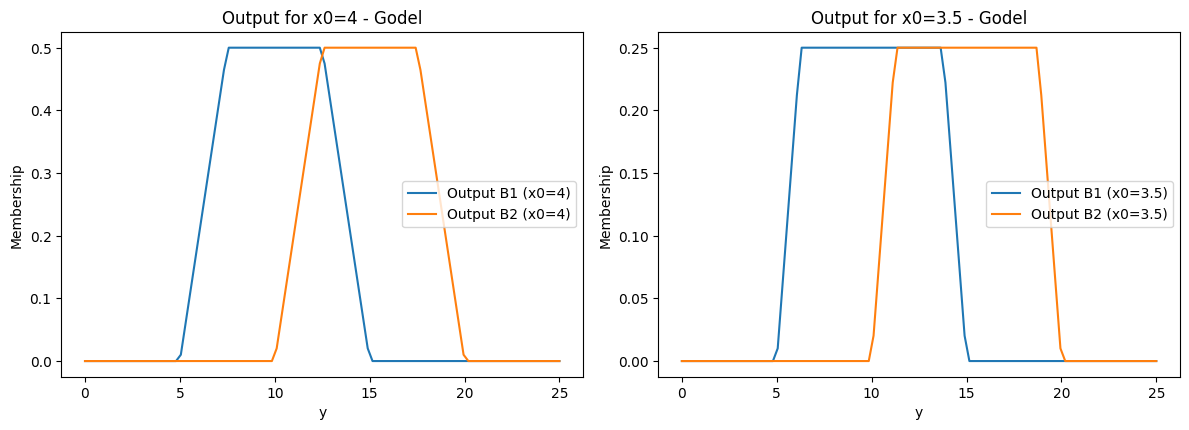

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Definición de las funciones de membresía triangulares
def triangular(x, a, b, c):
    return np.maximum(np.minimum((x-a)/(b-a), (c-x)/(c-b)), 0)

# Antecedentes
A1 = (1, 3, 5)
A2 = (3, 5, 7)

# Consecuentes
B1 = (5, 10, 15)
B2 = (10, 15, 20)

# Universo de discurso
x = np.linspace(0, 10, 100)
y = np.linspace(0, 25, 100)

# Funciones de membresía
A1_memb = triangular(x, *A1)
A2_memb = triangular(x, *A2)
B1_memb = triangular(y, *B1)
B2_memb = triangular(y, *B2)

# Entrada crisp
x0_a = 4
x0_b = 3.5

# Fuerza de disparo usando inferencia de Gödel
def firing_strength_godel(x0, A1_memb, A2_memb):
    mu_A1 = triangular(x0, *A1)
    mu_A2 = triangular(x0, *A2)
    return np.minimum(mu_A1, mu_A2)

# Salida difusa
def fuzzy_output_godel(firing_strength, B_memb):
    return np.minimum(firing_strength, B_memb)

# Calcular la fuerza de disparo
firing_strength_a = firing_strength_godel(x0_a, A1_memb, A2_memb)
firing_strength_b = firing_strength_godel(x0_b, A1_memb, A2_memb)

# Calcular la salida difusa
output_a_B1 = fuzzy_output_godel(firing_strength_a, B1_memb)
output_a_B2 = fuzzy_output_godel(firing_strength_a, B2_memb)
output_b_B1 = fuzzy_output_godel(firing_strength_b, B1_memb)
output_b_B2 = fuzzy_output_godel(firing_strength_b, B2_memb)

# Graficar los resultados
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(y, output_a_B1, label='Output B1 (x0=4)')
plt.plot(y, output_a_B2, label='Output B2 (x0=4)')
plt.title('Output for x0=4 - Godel')
plt.xlabel('y')
plt.ylabel('Membership')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(y, output_b_B1, label='Output B1 (x0=3.5)')
plt.plot(y, output_b_B2, label='Output B2 (x0=3.5)')
plt.title('Output for x0=3.5 - Godel')
plt.xlabel('y')
plt.ylabel('Membership')
plt.legend()

plt.tight_layout()
plt.show()


# Item 4.c

Si, las graficas y el resultado de la inferencia cambiaran si se utiliza la inferencia de Godel en vez de la de Mamdani.